In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, calculate_stats_from_random_points, smooth_data, merge_datasets, slice_by_dates

In [175]:
remote_df_a = load_and_prepare_data('../data/processed/satellites/Sentinel2_bands_indices_TCT_20m_202405-202605.csv')
remote_df_a = handle_duplicate_values(remote_df_a)
#remote_df_a = reindex_daily(remote_df_a)
no_stats = handle_outliers(remote_df_a, 3.0)
remote_df_a = calculate_stats_from_random_points(no_stats)

#remote_df_a = handle_missing_values(remote_df_a, 'time')
#remote_df_a = smooth_data(remote_df_a, None, 11, 2)

#z_df_a = remote_df_a.apply(zscore, nan_policy='omit')

In [176]:
no_stats
#2024-06-14

,B2_p01,B2_p02,B2_p03,B2_p04,B2_p05,B2_p06,B2_p07,B2_p08,B2_p09,B2_p10,...,wetness_p21,wetness_p22,wetness_p23,wetness_p24,wetness_p25,wetness_p26,wetness_p27,wetness_p28,wetness_p29,wetness_p30
Timestamps,,,,,,,,,,,,,,,,,,,,,
2024-05-20,0.3952,0.4120,0.4417,0.41880,0.4213,0.44350,0.40080,0.38430,0.41940,0.4045,...,-0.207256,-0.105222,-0.026215,-0.304681,-0.171502,-0.141681,-0.171996,-0.205101,-0.263304,-0.030292
2024-05-22,0.4224,0.4651,0.4998,0.45540,0.4482,0.48220,0.46400,0.40530,0.47160,0.4537,...,-0.262760,-0.179806,-0.105908,-0.334451,-0.225406,-0.214384,-0.241182,-0.228342,-0.296972,-0.132102
2024-05-25,0.3950,0.4218,0.4617,0.42130,0.4235,0.49800,0.42890,0.37320,0.42330,0.4084,...,-0.207313,-0.131052,-0.065236,-0.303795,-0.193600,-0.162808,-0.209603,-0.204793,-0.258452,-0.078952
2024-05-27,0.4185,0.4600,0.5137,0.44930,0.4413,0.53890,0.48000,0.39650,0.46080,0.4399,...,-0.210750,-0.133031,-0.051291,-0.321770,-0.193278,-0.164980,-0.212463,-0.208850,-0.269975,-0.071600
2024-05-30,0.4206,0.4483,0.5145,0.45060,0.4256,0.53640,0.46110,0.38850,0.45450,0.4324,...,-0.194443,-0.105108,-0.035252,-0.301469,-0.169538,-0.131960,-0.190377,-0.179893,-0.243194,-0.030236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-17,0.3442,0.3473,0.3606,0.35445,0.3592,0.43955,0.35695,0.33525,0.34995,0.3304,...,-0.112468,-0.063309,0.005916,-0.288551,-0.117821,-0.110096,-0.159960,-0.137670,-0.220160,-0.002656
2026-05-20,0.3568,0.3709,0.4151,0.37760,0.3922,0.49060,0.40230,0.34500,0.37420,0.3609,...,-0.138447,-0.083499,-0.023107,-0.309053,-0.133174,-0.140013,-0.190345,-0.149214,-0.246104,-0.024688
2026-05-22,0.3749,0.4143,0.4758,0.40830,0.4364,0.55870,0.47230,0.36580,0.41830,0.4061,...,-0.159099,-0.115455,-0.041047,-0.322437,-0.171967,-0.168131,-0.223725,-0.154095,-0.268950,-0.055539


In [177]:
remote_df_a

,B11_mean,B11_std,B11_median,B11_max,B11_min,B11_p25,B11_p75,B12_mean,B12_std,B12_median,...,str_min,str_p25,str_p75,wetness_mean,wetness_std,wetness_median,wetness_max,wetness_min,wetness_p25,wetness_p75
Timestamps,,,,,,,,,,,,,,,,,,,,,
2024-05-20,0.439563,0.058159,0.44720,0.5336,0.32010,0.412525,0.479775,0.331080,0.075125,0.32985,...,0.203832,0.282070,0.418373,-0.195293,0.086933,-0.204507,-0.024232,-0.362284,-0.252963,-0.147476
2024-05-22,0.506437,0.040532,0.52035,0.5576,0.41910,0.492100,0.534400,0.403593,0.051674,0.41580,...,0.175500,0.202832,0.262112,-0.252458,0.067716,-0.260854,-0.095191,-0.369975,-0.293496,-0.226140
2024-05-25,0.461637,0.044295,0.47480,0.5270,0.37420,0.431775,0.495100,0.356940,0.056208,0.36620,...,0.212267,0.257459,0.374083,-0.214338,0.072602,-0.221590,-0.055454,-0.344755,-0.254067,-0.196315
2024-05-27,0.487927,0.046746,0.50325,0.5535,0.38580,0.465050,0.522000,0.376880,0.062201,0.38900,...,0.180092,0.218863,0.307885,-0.220327,0.081108,-0.221542,-0.044961,-0.370741,-0.264568,-0.197171
2024-05-30,0.463803,0.052888,0.48390,0.5444,0.35940,0.441175,0.501875,0.350047,0.066462,0.36125,...,0.190642,0.247205,0.354077,-0.195234,0.084502,-0.198136,-0.018625,-0.357967,-0.239841,-0.171981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-17,0.382468,0.063433,0.38805,0.5155,0.27775,0.338713,0.419175,0.280495,0.077081,0.27375,...,0.228085,0.402791,0.646161,-0.160416,0.094841,-0.153734,0.016813,-0.359194,-0.218088,-0.111420
2026-05-20,0.418143,0.052902,0.42850,0.5179,0.32580,0.384550,0.446200,0.316647,0.070139,0.31710,...,0.224387,0.343694,0.492787,-0.184969,0.091052,-0.187033,-0.013832,-0.368292,-0.241683,-0.134492
2026-05-22,0.470353,0.045642,0.48915,0.5299,0.37490,0.442450,0.505900,0.353417,0.060073,0.36375,...,0.208524,0.241288,0.351488,-0.209345,0.087366,-0.220795,-0.027900,-0.365740,-0.266943,-0.160137


In [178]:
def plot_mean_with_std(stats_df: pd.DataFrame, feature: str, nStd: int=1):
    """
    Plot the mean feature value over time with a shaded area representing +/- one standard deviation.
    """
    # Set a clean seaborn style for scientific plots
    sns.set_theme(style="whitegrid")
    
    # Initialize the matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define the time axis (dataframe index) and the statistical series
    time_axis = stats_df.index
    mean = stats_df[f'{feature}_mean']
    std = stats_df[f'{feature}_std']
    
    # Calculate the upper and lower bounds for the standard deviation
    lower_bound = mean - (nStd*std)
    upper_bound = mean + (nStd*std)
    
    # Plot the mean line using seaborn
    sns.lineplot(
        x=time_axis, 
        y=mean, 
        label=f'mean {feature}', 
        color='gray',
        linewidth=2, 
        ax=ax
    )
    
    # Fill the area between lower and upper bounds using matplotlib
    ax.fill_between(
        time_axis, 
        lower_bound, 
        upper_bound, 
        color='gray',
        alpha=0.3,
        label='±1 std dev'
    )
    
    ax.set_ylabel(f'{feature} value')
    ax.set_xlabel('')
    ax.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    
    plt.show()

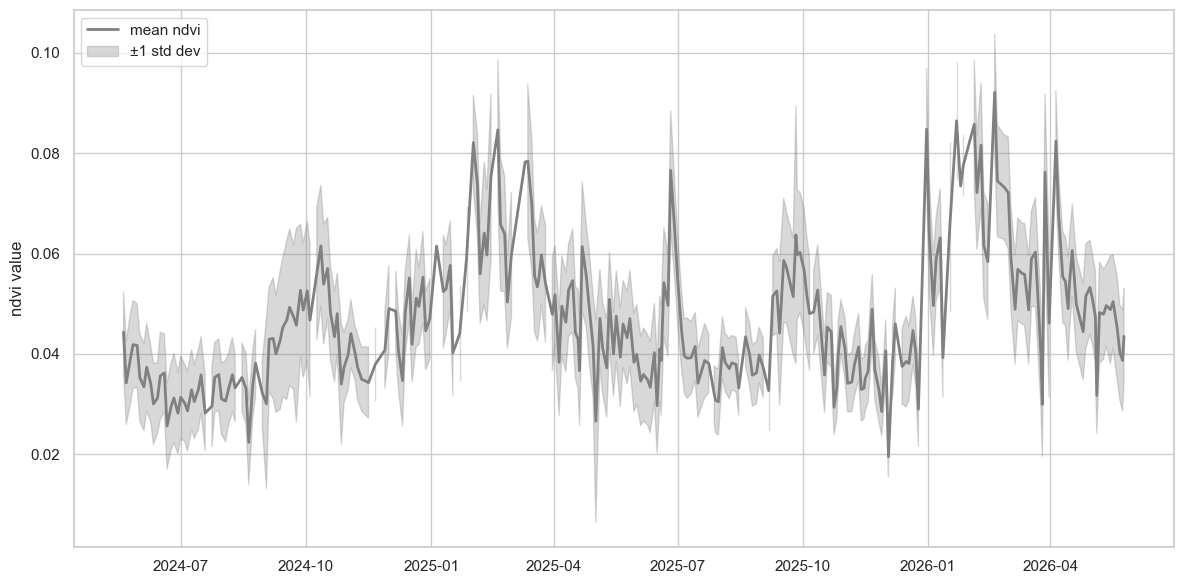

In [179]:
plot_mean_with_std(remote_df_a, 'ndvi', 1)